# 5DATA002W.2 Coursework - Final Python Notebook 2

**Author:** Thewan Jayaweera

**Peer Reviewer:** Namitha Danupama

**Date of Review:** 11/03/2026

**Reused from: Code Reuse Session 2 (Prompts 1, 5, 2)**

In [1]:
# Import pandas library to load and access the dataset
import pandas as pd

# Control the rows truncation when displaying the dataset
pd.set_option('display.max_rows', 500)

# Control the columns truncation when displaying the dataset
pd.set_option('display.max_columns', 500)

# Control the display width of the dataset
pd.set_option('display.width', 150)

# Load the classification dataset file
data = pd.read_csv('Classification_Loan_Data.csv')

**Reused from: Code Reuse Session 2 (Prompt 3)**

In [2]:
# Display the recorded data values for a sample of instances
data.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,payment_default_on_file,credit_history_length,loan_approval_status
0,0.009709,0.004114,2,0.000000,1,0.420290,0.094068,0,0.071429,0
1,0.009709,0.004747,2,0.013333,1,0.710145,0.680048,1,0.035714,0
2,0.029126,0.002848,3,0.033333,3,0.855072,0.419413,0,0.035714,0
3,0.194175,0.093788,3,0.020000,1,1.000000,0.154584,0,0.321429,0
4,0.194175,0.045258,0,0.020000,2,1.000000,0.419413,0,0.428571,0
5,0.194175,0.066887,0,0.060000,5,0.855072,0.148592,0,0.392857,0
6,0.194175,0.076907,0,0.060000,0,0.710145,0.387657,0,0.321429,0
7,0.194175,0.067412,0,0.020000,2,0.710145,0.683044,0,0.535714,0
8,0.194175,0.039983,0,0.013333,0,0.710145,0.289395,0,0.321429,0
9,0.194175,0.039983,0,0.060000,5,0.710145,0.793889,0,0.535714,0


**Reused from: Code Reuse Session 2 (Prompt 4)**

In [3]:
# Explore the data types for all the variables in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58631 entries, 0 to 58630
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58631 non-null  float64
 1   income                   58631 non-null  float64
 2   home_ownership           58631 non-null  int64  
 3   emplyment_length         58631 non-null  float64
 4   loan_intent              58631 non-null  int64  
 5   loan_amount              58631 non-null  float64
 6   loan_interest_rate       58631 non-null  float64
 7   payment_default_on_file  58631 non-null  int64  
 8   credit_history_length    58631 non-null  float64
 9   loan_approval_status     58631 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


**Reused from: Code Reuse Session 2 (Prompts 6, 7, 8)**

In [4]:
# Declare the input features
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'payment_default_on_file', 'credit_history_length']

# Assign input features to X
X = data[feature_cols]

# Assign output target feature to y
y = data['loan_approval_status']

# Load the package, module and function to randomly sample training and test subsets
from sklearn.model_selection import train_test_split

# Split the dataset into training and test subsets, ensuring reproducible sampling
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

**Reused from: Code Reuse Session 1 (Prompt 6)**

In [5]:
# Display the dimensions of the feature dataset
X.shape

(58631, 9)

**Reused from: Code Reuse Session 2 (Prompts 9, 10, 11, 12, 13, 15)**

In [6]:
# Load the machine learning package, module, and function to train the Logistic Regression modelling algorithm
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression modelling algorithm
logreg = LogisticRegression()

# Make LR learn the relationship between the inputs and outputs using the training subset
logreg.fit(X_train, y_train)

# Make predictions on the training data subset
y_pred_train = logreg.predict(X_train)

# Calculate and present the accuracy score for training data
from sklearn.metrics import accuracy_score
accuracy_train = accuracy_score(y_train, y_pred_train)
print ("The training accuracy is: ", accuracy_train)

# Use the model to make predictions on the unseen test dataset
y_pred = logreg.predict(X_test)

The training accuracy is:  0.879462001413221


**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18009,0,0
16396,0,0
32566,0,0
54723,0,0
54187,0,0
...,...,...
36192,0,0
25662,0,0
14118,0,0
39327,0,0


The accuracy is:  0.8792495736213758
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     15086
           1       0.76      0.22      0.35      2504

    accuracy                           0.88     17590
   macro avg       0.82      0.61      0.64     17590
weighted avg       0.87      0.88      0.85     17590



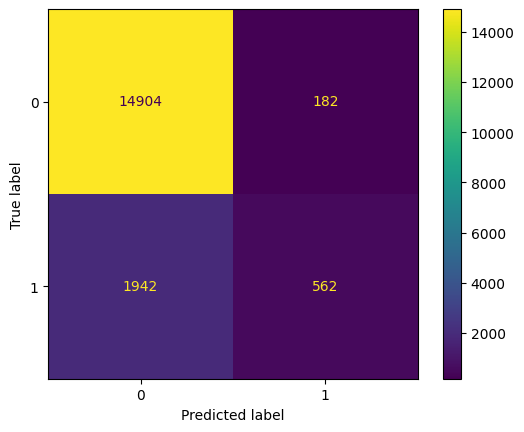

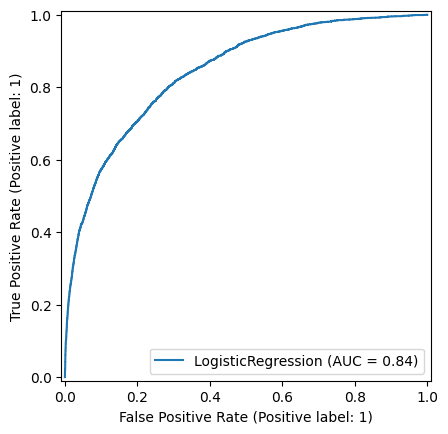

In [7]:
# Present a comparison of actual vs predicted status in a data frame
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Display the comparison dataframe
display(Comparison_df)

# Load the Python package, module and function to calculate the accuracy score
from sklearn.metrics import accuracy_score

# Calculate the accuracy score for the predictions on the test set
accuracy = accuracy_score(y_test, y_pred)

# Present the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Load the packages, modules and functions to plot a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)

# Instantiate the function to display the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)

# Plot the confusion matrix
disp.plot()

# Load the Python code block to produce the classification report
from sklearn.metrics import classification_report

# Print the classification report with combined performance metrics
print(classification_report(y_test, y_pred))

# Load the package to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Display the Area Under the ROC Curve
roc_disp = RocCurveDisplay.from_estimator(logreg, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompts 20, 21, 22, 23)**

In [8]:
# Load the Python package, module and machine learning algorithm function to use the KNN modelling algorithm
from sklearn.neighbors import KNeighborsClassifier

# Instantiate K-Nearest Neighbour modelling algorithm
knn = KNeighborsClassifier(n_neighbors = 5)

# Build the model using sampled training data subset
knn.fit(X_train,y_train)

# Predict the loan applications' status for clients in the isolated data subset using the model
y_pred = knn.predict(X_test)

**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18009,0,0
16396,0,0
32566,0,0
54723,0,0
54187,0,0
...,...,...
36192,0,0
25662,0,0
14118,0,0
39327,0,0


The accuracy is:  0.877771461057419
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     15086
           1       0.61      0.39      0.48      2504

    accuracy                           0.88     17590
   macro avg       0.76      0.67      0.70     17590
weighted avg       0.86      0.88      0.87     17590



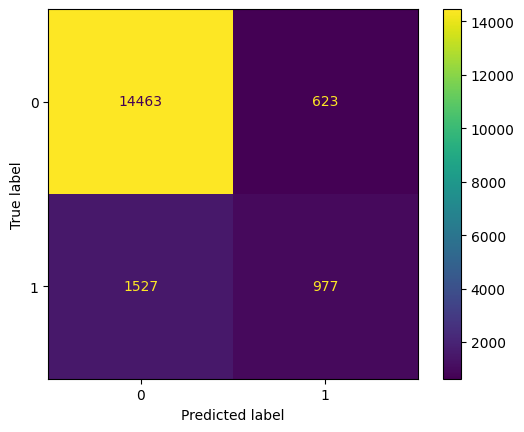

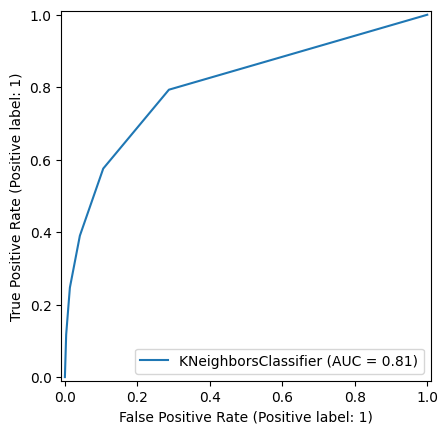

In [9]:
# Present a comparison of actual vs predicted status in a data frame
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Display the comparison dataframe
display(Comparison_df)

# Load the Python package, module and function to calculate the accuracy score
from sklearn.metrics import accuracy_score

# Calculate the accuracy score for the predictions on the test set
accuracy = accuracy_score(y_test, y_pred)

# Present the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Load the packages, modules and functions to plot a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels = knn.classes_)

# Instantiate the function to display the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = knn.classes_)

# Plot the confusion matrix
disp.plot()

# Load the Python code block to produce the classification report
from sklearn.metrics import classification_report

# Print the classification report with combined performance metrics
print(classification_report(y_test, y_pred))

# Load the package to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Display the Area Under the ROC Curve
roc_disp = RocCurveDisplay.from_estimator(knn, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompt 27)**

In [10]:
# Load the machine learning package, module and function for Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Instantiate the Naive Bayes modelling algorithm
nb = GaussianNB()

# Train it with training data subset to build a Naive Bayes classification model
nb.fit(X_train, y_train)

# Predict loan approval statuses on the test data subset
y_pred = nb.predict(X_test)

**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18009,0,1
16396,0,0
32566,0,0
54723,0,0
54187,0,0
...,...,...
36192,0,0
25662,0,0
14118,0,0
39327,0,0


The accuracy is:  0.8358158044343377
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     15086
           1       0.43      0.44      0.44      2504

    accuracy                           0.84     17590
   macro avg       0.67      0.67      0.67     17590
weighted avg       0.84      0.84      0.84     17590



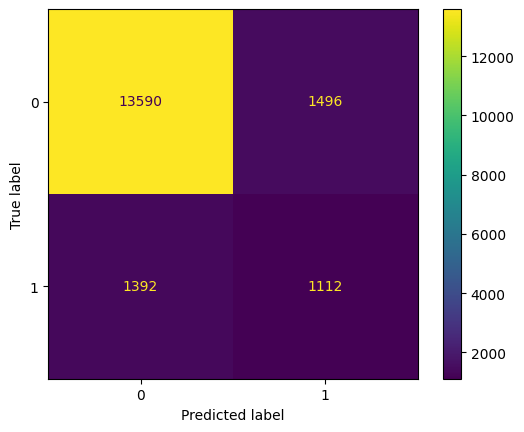

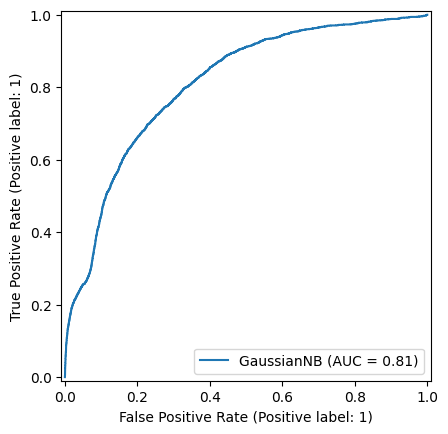

In [11]:
# Present a comparison of actual vs predicted status in a data frame
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Display the comparison dataframe
display(Comparison_df)

# Load the Python package, module and function to calculate the accuracy score
from sklearn.metrics import accuracy_score

# Calculate the accuracy score for the predictions on the test set
accuracy = accuracy_score(y_test, y_pred)

# Present the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Load the packages, modules and functions to plot a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels = nb.classes_)

# Instantiate the function to display the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = nb.classes_)

# Plot the confusion matrix
disp.plot()

# Load the Python code block to produce the classification report
from sklearn.metrics import classification_report

# Print the classification report with combined performance metrics
print(classification_report(y_test, y_pred))

# Load the package to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Display the Area Under the ROC Curve
roc_disp = RocCurveDisplay.from_estimator(nb, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompts 24, 25, 26)**

In [12]:
# Load GrideSearchCV to perform cross-validation
from sklearn.model_selection import GridSearchCV

# Specify multiple values for each hyperparameter in the search setup
param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

# Tune the model's hyperparameters using cross-validation
knn_gscv = GridSearchCV(knn, param_grid, cv = 5)

# Fit the exhaustive hyperparameter search to the data
knn_gscv.fit(X_train, y_train)

# Display the best hyperparameter configurations
print(knn_gscv.best_params_)

# Use the built model with optimised hyperparameter configurations to predict statuses
y_pred = knn_gscv.predict(X_test)

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}


**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18009,0,0
16396,0,0
32566,0,0
54723,0,0
54187,0,0
...,...,...
36192,0,0
25662,0,0
14118,0,0
39327,0,0


The accuracy is:  0.888857305287095
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     15086
           1       0.69      0.40      0.51      2504

    accuracy                           0.89     17590
   macro avg       0.80      0.69      0.72     17590
weighted avg       0.88      0.89      0.88     17590



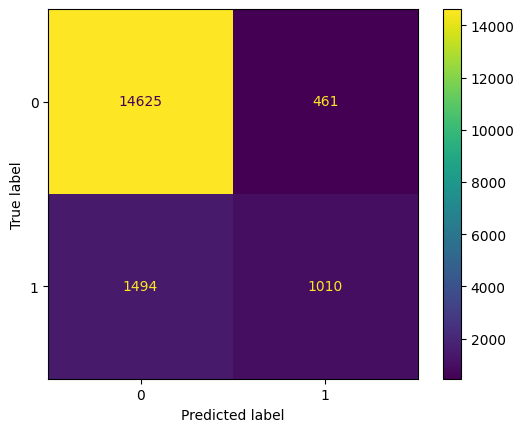

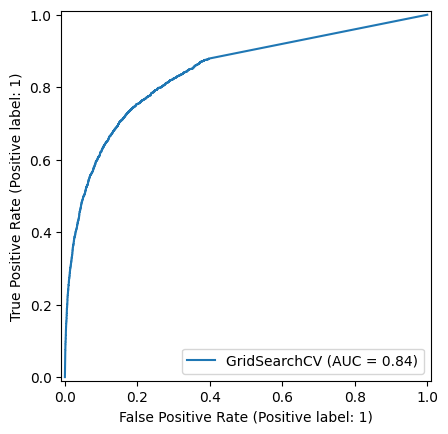

In [13]:
# Present a comparison of actual vs predicted status in a data frame
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Display the comparison dataframe
display(Comparison_df)

# Load the Python package, module and function to calculate the accuracy score
from sklearn.metrics import accuracy_score

# Calculate the accuracy score for the predictions on the test set
accuracy = accuracy_score(y_test, y_pred)

# Present the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Load the packages, modules and functions to plot a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels = knn_gscv.classes_)

# Instantiate the function to display the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = knn_gscv.classes_)

# Plot the confusion matrix
disp.plot()

# Load the Python code block to produce the classification report
from sklearn.metrics import classification_report

# Print the classification report with combined performance metrics
print(classification_report(y_test, y_pred))

# Load the package to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Display the Area Under the ROC Curve
roc_disp = RocCurveDisplay.from_estimator(knn_gscv, X_test, y_test)